# EDA — SPY daily returns and volatility clustering

Exploratory only (TASKS.md Phase 1). Checks the basic distributional
properties of daily log returns, volatility clustering, and the shape of
the 5-day forward realized-variance target defined in `src/target.py`.

**Scope note (DECISIONS.md ADR-001):** this notebook uses the full sample,
including periods that will later be out-of-sample. It looks only at
well-established stylized facts and computes no model performance numbers;
no model parameter is chosen from it.

Run `python -m src.data` first to build `data/processed/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_processed  # noqa: E402
from src.target import HORIZON, forward_realized_variance  # noqa: E402

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "lines.linewidth": 1.0, "figure.dpi": 110,
})
TRADING_DAYS = 252

df = load_processed()
r = df["log_return"]
print(f"{len(r):,} daily log returns, {r.index[0].date()} to {r.index[-1].date()}")

8,287 daily log returns, 1993-02-01 to 2025-12-31


## 1. Price and returns

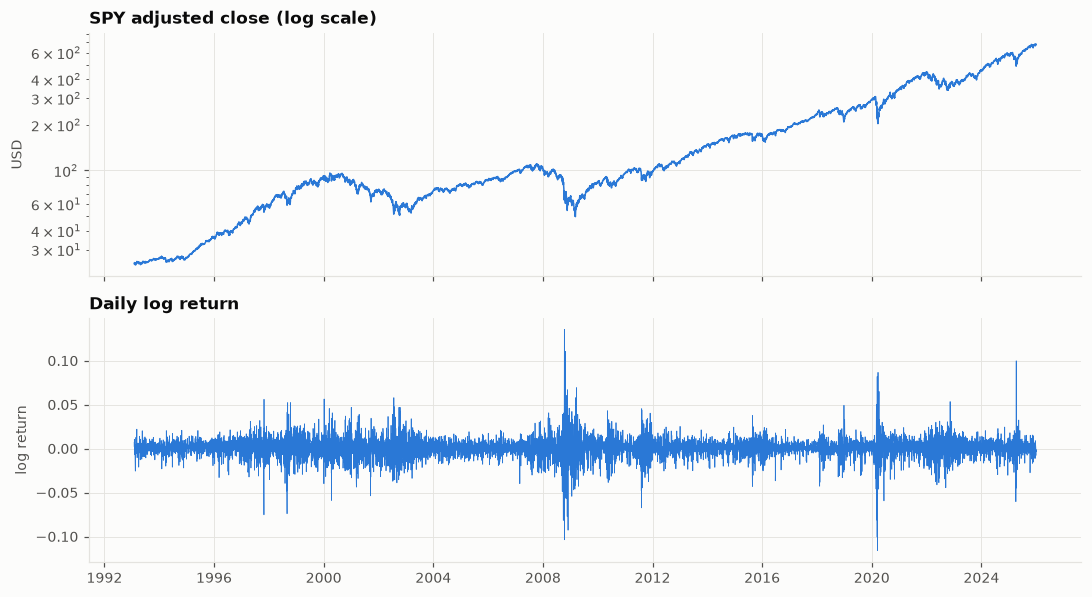

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
ax1.plot(df.index, df["close"], color=BLUE)
ax1.set_yscale("log")
ax1.set_title("SPY adjusted close (log scale)")
ax1.set_ylabel("USD")
ax2.plot(r.index, r, color=BLUE, linewidth=0.5)
ax2.set_title("Daily log return")
ax2.set_ylabel("log return")
fig.tight_layout()

## 2. Return distribution

In [3]:
jb = stats.jarque_bera(r)
summary = pd.Series({
    "observations": len(r),
    "mean (annualized)": r.mean() * TRADING_DAYS,
    "volatility (annualized)": r.std() * np.sqrt(TRADING_DAYS),
    "skewness": stats.skew(r),
    "excess kurtosis": stats.kurtosis(r),
    "min daily return": r.min(),
    "min date": r.idxmin().date(),
    "max daily return": r.max(),
    "max date": r.idxmax().date(),
    "zero-return days": int((r == 0).sum()),
    "Jarque-Bera statistic": jb.statistic,
    "Jarque-Bera p-value": jb.pvalue,
})
summary.to_frame("value")

,value
observations,8287
mean (annualized),0.101471
volatility (annualized),0.186422
skewness,-0.248537
excess kurtosis,11.396995
min daily return,-0.115887
min date,2020-03-16
max daily return,0.135577
max date,2008-10-13
zero-return days,62


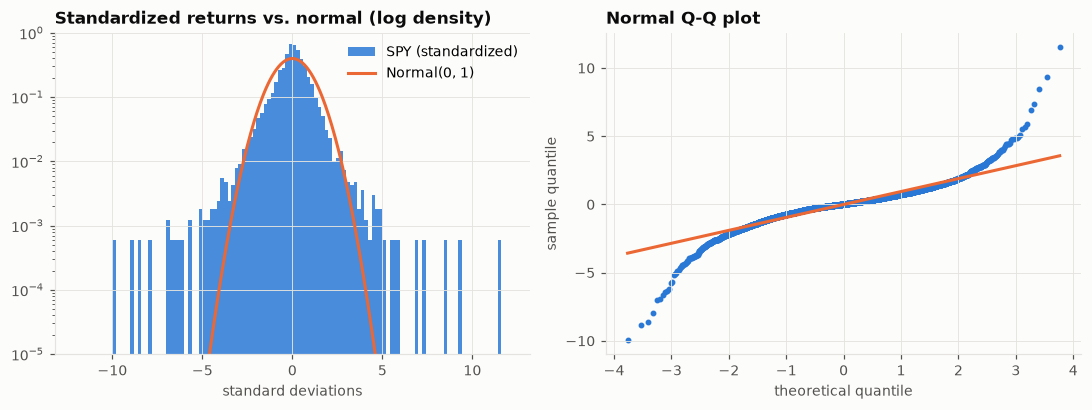

In [4]:
z = (r - r.mean()) / r.std()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

bins = np.linspace(-12, 12, 121)
ax1.hist(z, bins=bins, density=True, color=BLUE, alpha=0.85, label="SPY (standardized)")
grid = np.linspace(-12, 12, 400)
ax1.plot(grid, stats.norm.pdf(grid), color=ORANGE, linewidth=2, label="Normal(0, 1)")
ax1.set_yscale("log")
ax1.set_ylim(1e-5, 1)
ax1.set_title("Standardized returns vs. normal (log density)")
ax1.set_xlabel("standard deviations")
ax1.legend(frameon=False)

(osm, osr), (slope, intercept, _) = stats.probplot(z, dist="norm")
ax2.scatter(osm, osr, s=8, color=BLUE)
ax2.plot(osm, slope * osm + intercept, color=ORANGE, linewidth=2)
ax2.set_title("Normal Q-Q plot")
ax2.set_xlabel("theoretical quantile")
ax2.set_ylabel("sample quantile")
fig.tight_layout()

## 3. Volatility clustering

Returns themselves should show little autocorrelation, while their
magnitude (|r| and r²) should be strongly and persistently autocorrelated.
Dashed lines are approximate 95% bands (±1.96/√n) under the null of no
autocorrelation.

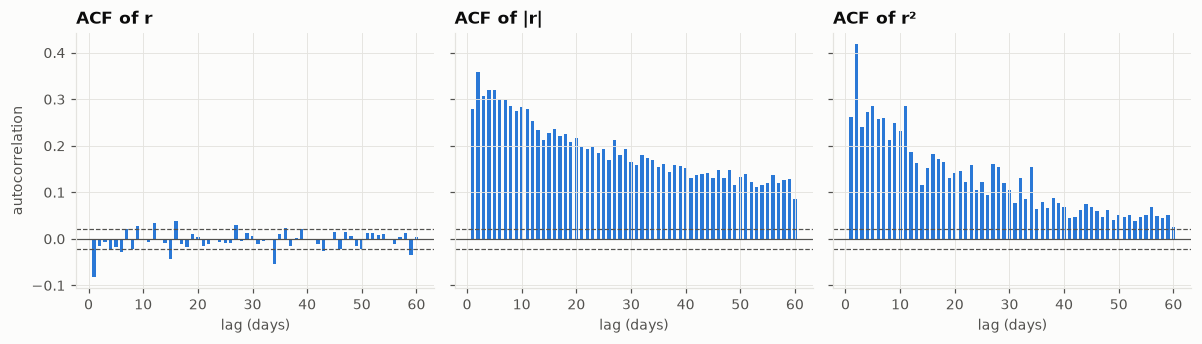

In [5]:
lags = 60
band = 1.96 / np.sqrt(len(r))
series = {"r": r, "|r|": r.abs(), "r²": r**2}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (name, s) in zip(axes, series.items()):
    rho = acf(s, nlags=lags, fft=True)[1:]
    ax.bar(np.arange(1, lags + 1), rho, width=0.6, color=BLUE)
    for b in (band, -band):
        ax.axhline(b, color=MUTED, linestyle="--", linewidth=0.8)
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.set_title(f"ACF of {name}")
    ax.set_xlabel("lag (days)")
axes[0].set_ylabel("autocorrelation")
fig.tight_layout()

In [6]:
lb = pd.concat(
    {name: acorr_ljungbox(s, lags=[5, 10, 20]) for name, s in series.items()},
    names=["series", "lag"],
)
lb

lb_stat     lb_pvalue
series lag                            
r      5       64.247888  1.604989e-12
       10      83.898922  8.603109e-14
       20     126.243268  1.967852e-17
|r|    5     4196.058829  0.000000e+00
       10    7656.996565  0.000000e+00
       20   12127.884993  0.000000e+00
r²     5     3794.776038  0.000000e+00
       10    6246.768297  0.000000e+00
       20    8796.741389  0.000000e+00

,21d vol
count,8267.000000
mean,0.158953
std,0.099993
min,0.034158
25%,0.096556
50%,0.133910
75%,0.193070
max,0.936684


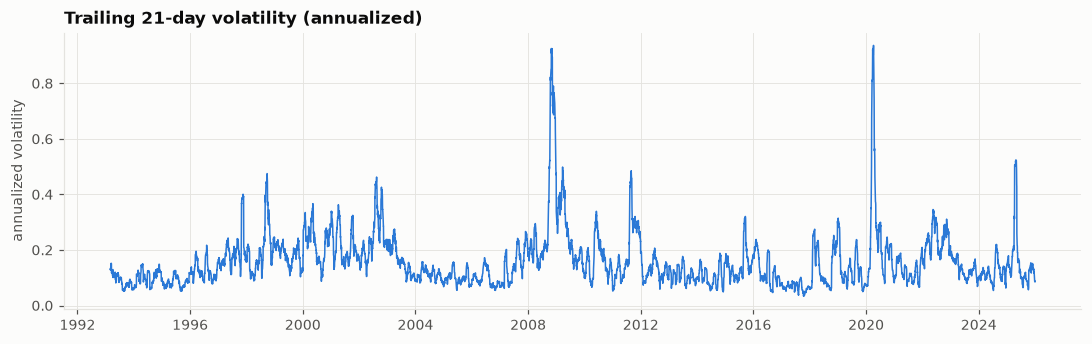

In [7]:
rolling_vol = r.rolling(21).std() * np.sqrt(TRADING_DAYS)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(rolling_vol.index, rolling_vol, color=BLUE)
ax.set_title("Trailing 21-day volatility (annualized)")
ax.set_ylabel("annualized volatility")
fig.tight_layout()
rolling_vol.describe().to_frame("21d vol")

## 4. The forecasting target

`forward_realized_variance` gives, at each day t, the sum of squared log
returns over t+1 … t+5 (DECISIONS.md ADR-002). For readability it is also
shown as an annualized volatility, √(RV × 252 / 5).

Consecutive daily targets share 4 of their 5 returns, so their ACF is
mechanically high at lags 1–4. To see the persistence of volatility
itself, the ACF below uses **non-overlapping** weeks (every 5th target).

In [8]:
rv = forward_realized_variance(r).dropna()
ann_vol = np.sqrt(rv * TRADING_DAYS / HORIZON)
pd.DataFrame({
    f"RV ({HORIZON}d variance)": rv.describe(),
    "annualized vol equivalent": ann_vol.describe(),
})

,RV (5d variance),annualized vol equivalent
count,8282.000000,8282.000000
mean,0.000691,0.150454
std,0.001682,0.110320
min,0.000002,0.008997
25%,0.000133,0.081776
50%,0.000301,0.123270
75%,0.000689,0.186330
max,0.035737,1.342075


weeks with RV == 0: 0


log RV: skew 0.05, excess kurtosis 0.44
non-overlapping weekly ACF of log RV at lags 1, 4, 13, 52: 0.58, 0.45, 0.29, 0.11


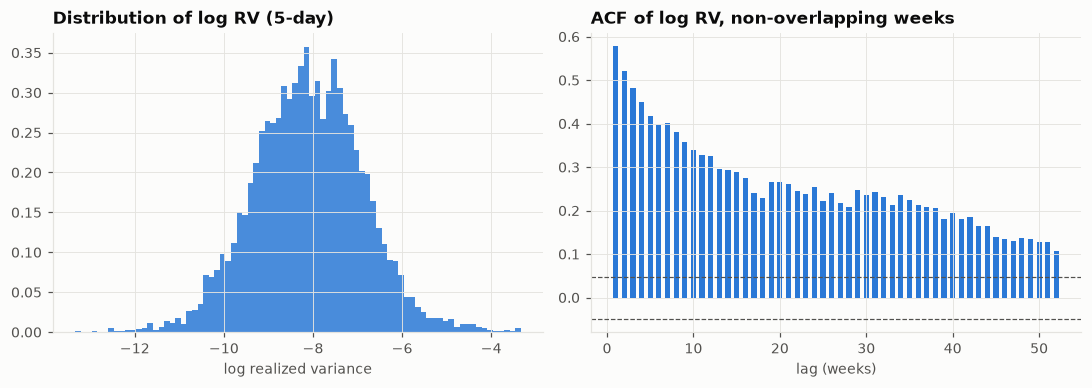

In [9]:
print(f"weeks with RV == 0: {int((rv == 0).sum())}")
log_rv = np.log(rv[rv > 0])
weekly = log_rv.iloc[::HORIZON]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.hist(log_rv, bins=80, density=True, color=BLUE, alpha=0.85)
ax1.set_title(f"Distribution of log RV ({HORIZON}-day)")
ax1.set_xlabel("log realized variance")

lags = 52
rho = acf(weekly, nlags=lags, fft=True)[1:]
ax2.bar(np.arange(1, lags + 1), rho, width=0.6, color=BLUE)
b = 1.96 / np.sqrt(len(weekly))
for v in (b, -b):
    ax2.axhline(v, color=MUTED, linestyle="--", linewidth=0.8)
ax2.set_title("ACF of log RV, non-overlapping weeks")
ax2.set_xlabel("lag (weeks)")
fig.tight_layout()
print(f"log RV: skew {stats.skew(log_rv):.2f}, excess kurtosis {stats.kurtosis(log_rv):.2f}")
print(f"non-overlapping weekly ACF of log RV at lags 1, 4, 13, 52: "
      f"{rho[0]:.2f}, {rho[3]:.2f}, {rho[12]:.2f}, {rho[51]:.2f}")

### Leverage effect

Negative returns tend to be followed by higher volatility than positive
returns of the same size. A simple check: the rank correlation between
today's return and the log of next week's realized variance.

In [10]:
aligned = pd.concat({"r_t": r, "log_rv_fwd": np.log(rv[rv > 0])}, axis=1).dropna()
rho_s = stats.spearmanr(aligned["r_t"], aligned["log_rv_fwd"])
down = aligned.loc[aligned["r_t"] < 0, "log_rv_fwd"].mean()
up = aligned.loc[aligned["r_t"] > 0, "log_rv_fwd"].mean()
print(f"Spearman(r_t, log RV_t+1..t+5) = {rho_s.statistic:.3f} (p = {rho_s.pvalue:.1e})")
print(f"mean log RV after down days {down:.3f} vs. after up days {up:.3f}")

Spearman(r_t, log RV_t+1..t+5) = -0.135 (p = 6.5e-35)
mean log RV after down days -7.903 vs. after up days -8.251


## Observations

Numbers below are the outputs printed above (full sample, 8,287 daily
returns, 1993-02-01 to 2025-12-31).

1. **Fat tails, mild negative skew.** Excess kurtosis is 11.4 and skewness
   −0.25; Jarque–Bera rejects normality decisively. The largest moves are
   +13.6% (2008-10-13) and −11.6% (2020-03-16). Annualized volatility over
   the full sample is 18.6%.
2. **Strong volatility clustering.** The autocorrelations of |r| and r² are
   large, positive and decay slowly; the Ljung–Box statistic at lag 20 is
   about 12,100 for |r| versus about 126 for r itself. Trailing 21-day
   volatility ranges from 3.4% to 93.7% annualized (median 13.4%), so the
   sample covers very different volatility regimes.
3. **Returns are not exactly white noise.** Lag-1 autocorrelation of r is
   negative (about −0.08, outside the ±1.96/√n band), and Ljung–Box rejects
   at lags 5–20. The standard Ljung–Box test assumes constant variance and
   overstates significance under volatility clustering, but either way this
   linear dependence is small compared with the dependence in |r| and r².
   The target uses squared returns without demeaning (ADR-002).
4. **The target is heavily right-skewed in levels and roughly symmetric in
   logs.** Five-day RV has mean 0.00069 against median 0.00030 and a maximum
   of 0.0357 (about 134% annualized). log RV has skewness 0.05 and excess
   kurtosis 0.44. No week has RV = 0.
5. **Volatility is persistent at the forecast horizon and beyond.** On
   non-overlapping weeks, the autocorrelation of log RV is 0.58 at 1 week,
   0.45 at 4 weeks, 0.29 at 13 weeks and 0.11 at 52 weeks.
6. **Leverage effect is present.** Spearman correlation between r_t and
   log RV over t+1…t+5 is −0.135 (p ≈ 6.5e-35); mean log RV is −7.90 after
   down days versus −8.25 after up days.

These are the standard stylized facts of equity-index returns. As stated
in the scope note, nothing here was used to choose a model parameter.